In [8]:
# =====================================================================
# CELDA 1: PREPARACIÓN DEL ENTORNO E IMPORTACIÓN DE LIBRERÍAS
# =====================================================================

# Instalación de librerías (Quitar el siguiente '#' inicial si el PC no las tiene instaladas)
# %pip install numpy scipy matplotlib scikit-image scikit-learn

# 1. Librerías matemáticas y de grafos
import numpy as np
from scipy.spatial.distance import cdist
from scipy.sparse import csr_matrix, csgraph
from scipy.sparse.linalg import eigsh

# 2. Librerías de Machine Learning
from sklearn.cluster import SpectralClustering

# 3. Librerías de procesamiento de imágenes (para cargar la foto)
from skimage import io, transform, color

# 4. Librerías visuales (Para pintar las gráficas y las fotos finales)
import matplotlib.pyplot as plt

In [9]:
# =====================================================================
# CELDA 2: DEFINICIÓN DE LA FUNCIÓN DE AFINIDAD (KERNEL)
# =====================================================================

def calcular_mi_afinidad(dist_matrix, tipo='gaussiana', parametro=0.2):
    """
    Función para calcular la matriz de afinidad a partir de las distancias.
    
    Argumentos:
    - dist_matrix: Matriz de distancias precalculada.
    - tipo: Nombre de la función matemática a aplicar ('gaussiana', 'lineal', 'umbral', etc.).
    - parametro: Controla la anchura o límite de la función (ej. la varianza en la gaussiana).
    """
    
    if tipo == 'gaussiana':
        # La clásica campana de Gauss 
        return np.exp(- (dist_matrix ** 2) / (2.0 * parametro ** 2))
        
    elif tipo == 'lineal':
        # Cae de forma constante hasta llegar a 0 (basado en la máxima distancia de la foto)
        afinidad = 1 - (dist_matrix / np.max(dist_matrix))
        return np.maximum(0, afinidad) # Evitamos afinidades negativas
        
    elif tipo == 'umbral':
        # Todo o nada: Afinidad es 1 si están cerca, 0 si están lejos
        return (dist_matrix < parametro).astype(float)
        
    elif tipo == 'cauchy':
        # Colas más pesadas, útil para aislar ruido
        return 1.0 / (1.0 + (dist_matrix ** 2 / parametro ** 2))
        
    elif tipo == 'multicuadratica':
        # Caída con una suavidad extrema a lo largo de la distancia
        return 1.0 / np.sqrt(dist_matrix ** 2 + parametro ** 2)
        
    elif tipo == 'paso_fino':
        # Gaussiana truncada: muere a 0 absoluto tras cierta distancia (ahorra RAM)
        afinidad = np.exp(- (dist_matrix ** 2) / (2.0 * parametro ** 2))
        afinidad[dist_matrix > parametro * 3] = 0
        return afinidad
        
    else:
        # Seguro por si escribes mal el nombre del tipo al llamar a la función
        raise ValueError("Tipo de afinidad no reconocido")

In [10]:
# =====================================================================
# CELDA 3: PREPARACIÓN DE LA MATRIZ DE DATOS (X_features)
# =====================================================================

# 1. Cargar y redimensionar la imagen
archivo_imagen = 'frutas.png'
alto, ancho = 100, 100  # Resolución a la que vamos a trabajar (10.000 píxeles)

img_original = io.imread(archivo_imagen)
img_small = transform.resize(img_original, (alto, ancho)) 

#2. Características del color
# 2a. Extraer espacios de color (RGB y HSV)
# Nos quedamos solo con los 3 primeros canales (RGB) por si la imagen tiene canal Alpha (transparencia)
img_rgb = img_small[:, :, :3]
img_hsv = color.rgb2hsv(img_rgb)

# 2b. Aplanar las matrices (de matriz 100x100 a vectores de 10.000 elementos)
# Canales RGB
R = img_rgb[:, :, 0].flatten() 
G = img_rgb[:, :, 1].flatten() 
B = img_rgb[:, :, 2].flatten() 

# Canales HSV
H = img_hsv[:, :, 0].flatten() # Matiz/Tono (Ángulo en la rueda de color: de 0 a 1)
S = img_hsv[:, :, 1].flatten() # Saturación (Intensidad: de 0 a 1)
V = img_hsv[:, :, 2].flatten() # Valor (Brillo: de 0 a 1)

# 2c. Truco Matemático: Coordenadas Polares para H y S.
# Como la matriz H es cíclica (el inicio y el final son el mismo color), 
# pasamos el ángulo a coordenadas (x,y) en un círculo de radio S.
color_x = S * np.cos(2 * np.pi * H) 
color_y = S * np.sin(2 * np.pi * H)

# 3. Características del espacio (Posición X e Y de cada píxel)
# 3a. Creamos una matriz de coordenadas
# meshgrid crea dos matrices 100x100: 'xx' guarda el índice de la columna (0, 1, ..., 99), 'yy' guarda el índice de la fila (0, 1, ..., 99)
xx, yy = np.meshgrid(np.arange(ancho), np.arange(alto))

# 3b. Pasamos las matrices a vectores de 10k dim y normalizamos dividiendo entre ancho/alto para que vayan de 0 a 1 (al igual que los colores)
espacio_x = xx.flatten() / ancho 
espacio_y = yy.flatten() / alto  

# 4. Construcción de la Matriz Final (Píxeles x Características)
alfa = 0.4  # Peso que le damos a la cercanía espacial vs similitud de color

# Unimos las columnas con column_stack. 
# Resultado: Matriz de 10.000 filas (píxeles) x 5 columnas (características)
X_features_rgb = np.column_stack((R, G, B, alfa * espacio_x, alfa * espacio_y)) 
X_features_hsv = np.column_stack((color_x, color_y, V, alfa * espacio_x, alfa * espacio_y)) 

In [11]:
# =====================================================================
# CELDA 4: CÁLCULO DE DISTANCIAS Y MATRIZ DE AFINIDAD
# =====================================================================

# 1. Cálculo de la Matriz de Distancias
# 'cdist' compara cada fila de la primera matriz con todas las de la segunda, apuntando los resultados fila a fila para crear una matriz de 10.000 x 10.000.
# - Args 1 y 2: Las matrices que queremos comparar.
# - Arg 'metric': La distancia a usar (acepta 'euclidean', 'cityblock', 'cosine', 'minkowski'...).
# - Args extra (opcionales): Parámetros que necesiten ciertas normas (ej. 'p' para Minkowski).
dist_matrix = cdist(X_features_hsv, X_features_hsv, metric='euclidean') 

# 2. Matriz de Afinidad W
# Parámetros a elegir:
tipo_elegido = 'gaussiana'
parametro_elegido = 0.1  # Este es el valor que ensancha o estrecha la función. ¡Varíalo!

matriz_afinidad = calcular_mi_afinidad(dist_matrix, tipo=tipo_elegido, parametro=parametro_elegido)

<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
/var/folders/t9/1cdp8l8914g1t_zv2cgw_zd80000gn/T/ipykernel_2858/545918256.py:33: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Valor del Autovalor ($\lambda$)')


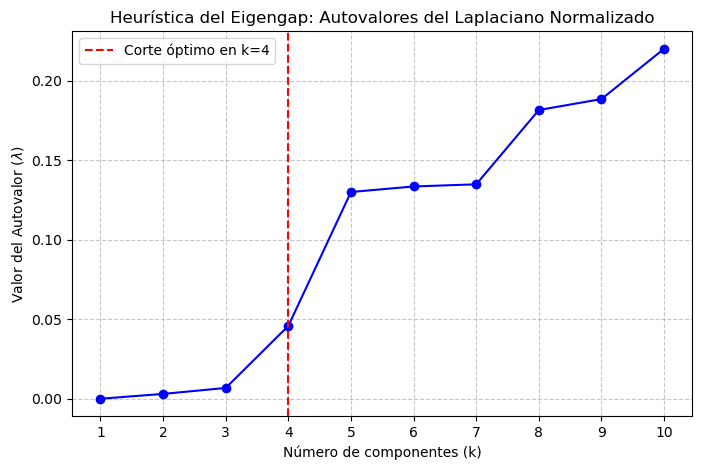

In [12]:
# =====================================================================
# CELDA 5: CÁLCULO DEL NÚMERO DE CLÚSTERES (K) MEDIANTE AUTOVALORES
# =====================================================================

# 1. Comprimimos la matriz de afinidad a formato "Disperso" (Sparse)
# Esto ignora los ceros para facilitar los cálculos sobre la matriz afinidad
W_matriz = csr_matrix(matriz_afinidad)

# 2. Calculamos la Matriz Laplaciana Normalizada
# La función csgraph.laplacian hace automáticamente: L = D^(-1/2) *(D-W) * D^(-1/2)
L_norm = csgraph.laplacian(W_matriz, normed=True)

# 3. Calculamos solo los 10 autovalores más pequeños (k=10; 'SA' significa Smallest Algebraic)
# eigsh devuelve los autovalores y los autovectores (estos últimos los ignoramos con '_')
max = 10
autovalores, _ = eigsh(L_norm, k=max, which='SA')
# Ordenamos los autovalores de menor a mayor
autovalores = np.sort(autovalores)

# 4. Buscamos el Eigengap (el salto más grande entre un autovalor y el siguiente)
# np.diff resta cada número menos el anterior y nos da el vector: [L2-L1, L3-L2, L4-L3...]
gaps = np.diff(autovalores)
# Escogemos el salto mas grande desde el segundo (ignoramos k=1); sumamos 2 para obtener el número de clústers (en vez de la posición)
k_optimo = np.argmax(gaps[1:]) + 2 


# --- DIBUJAMOS LA GRÁFICA ---
plt.figure(figsize=(8, 5))
# Dibujamos los puntos (sumamos 1 al índice porque el primer autovalor corresponde a k=1)
plt.plot(range(1, max+1), autovalores, marker='o', linestyle='-', color='b')
plt.title('Heurística del Eigengap: Autovalores del Laplaciano Normalizado')
plt.xlabel('Número de componentes (k)')
plt.ylabel('Valor del Autovalor ($\lambda$)')
plt.xticks(range(1, max+1))

# Dibujamos una línea roja discontinua para señalar el k que ha elegido el programa
plt.axvline(x=k_optimo, color='r', linestyle='--', label=f'Corte óptimo en k={k_optimo}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('autovalores_frutas.png')
plt.show()


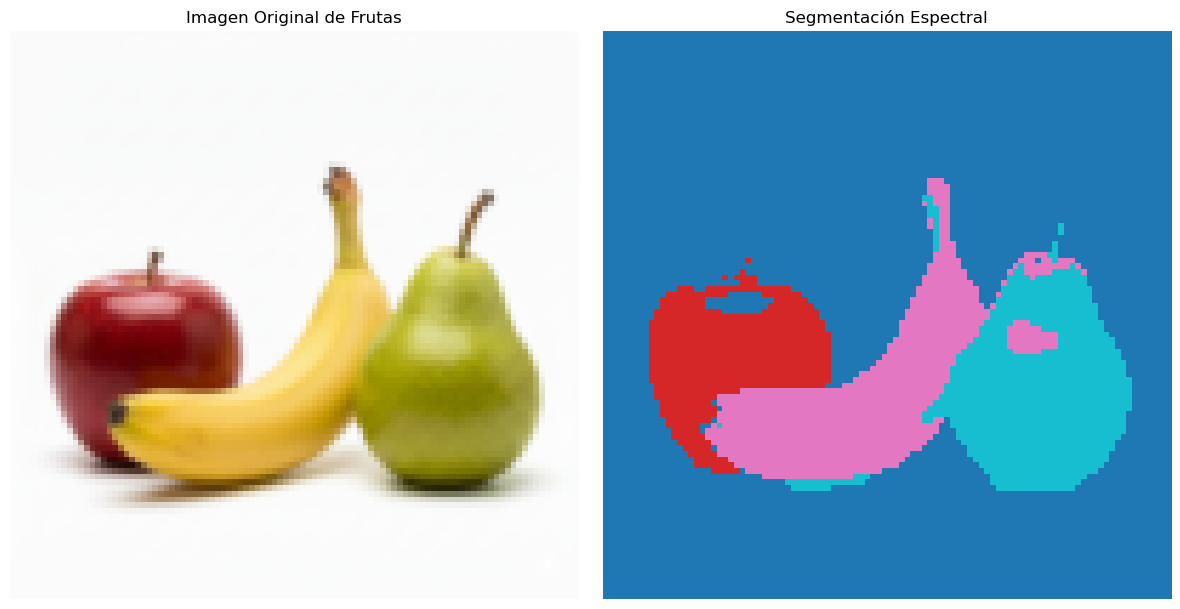

In [13]:

# =====================================================================
# CELDA 6: EJECUCIÓN DEL SPECTRAL CLUSTERING
# =====================================================================

# 1. Configuración del Modelo.
# - n_clusters: El número óptimo que calculamos con el eigengap.
# - affinity: 'precomputed' porque ya hemos calculado nuestra matriz W.
# - random_state: Semilla para el K-Means interno; asegura que el resultado no varíe entre ejecuciones.
sc = SpectralClustering(n_clusters=k_optimo, affinity='precomputed', random_state=42)

# 2. Entrenamiento y Asignación de Etiquetas (Fase Final)
# fit_predict calcula los autovectores y les aplica K-Means para agrupar.
# Resultado: Vector de 10.000 elementos donde cada píxel recibe una etiqueta (0, 1, ..., k-1).
etiquetas_planas = sc.fit_predict(matriz_afinidad)


# PREPARAMOS EL LIENZO
# figsize=(12, 6) significa 12 pulgadas de ancho y 6 de alto (para que quepan dos imágenes 6x6 pulgadas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# --- PRIMER SUBPLOT (Imagen Original) ---
# axes[0] es la primera "caja/lienzo" (la de la izquierda, donde voy a colocar la imagen original)
axes[0].imshow(img_small) # Aquí cargamos tu imagen original de frutas 100x100
axes[0].set_title("Imagen Original de Frutas")#le ponemos título a la imagen
axes[0].axis('off') #Quitamos los ejes coordenados para que se vea limpio

# --- SEGUNDO SUBPLOT (Segmentación) ---
#Lo pasamos a una matriz 100x100 en vez de el vector etiquetas_planas de 10.000 componentes, para reconstruir la nueva imagen
imagen_segmentada = etiquetas_planas.reshape(alto, ancho)
# axes[1] es la segunda "caja/lienzo" (la de la derecha, donde voy a colocar la imagen de los clusters)
axes[1].imshow(imagen_segmentada, cmap='tab10')
axes[1].set_title("Segmentación Espectral")#le ponemos título a la imagen
axes[1].axis('off')#Quitamos los ejes coordenados para que se vea limpio

# 2. AJUSTE FINAL (Para que los títulos no se pisen)
plt.tight_layout()

# 3. MOSTRAR TODO EL LIENZO
plt.savefig('segmentacion_frutas_final.png')
plt.show()

